
# Drift — Comparación de estrategias y métricas (Notebook Limpio)

## 1) Setup

In [ ]:

from pathlib import Path
import pandas as pd
import numpy as np

import importlib, sys, json, textwrap, os
drift = importlib.import_module('Funciones_Drift')

SciPy disponible: True


## 2) Parámetros del experimento

In [ ]:
plant_files = {
    'planta1': Path('../df_procesados/df_planta_1.csv'),
    'planta2': Path('../df_procesados/df_planta_2.csv'),
    'planta3': Path('../df_procesados/df_planta_3.csv'),
}

flag_files = {
    'planta1': Path('../df_procesados/flags_p1.csv'),
    'planta2': Path('../df_procesados/flags_p2.csv'),
    'planta3': Path('../df_procesados/flags_p3.csv'),
}

plants = list(plant_files.keys())
strategies = ['decay', 'golden', 'seasonal']
metrics = [ 'ks', 'mannwhitney', 'psi', 'wasserstein']

# Ventanas y muestreos
CURRENT_WINDOW = '3D'
RESAMPLE = None
RESAMPLE_AGG = 'mean'

# Exclusiones (por nombre exacto de columna)
EXCLUDE_COLUMNS = ['pH Ecualizador 2 (Tk 250m3)', "Conductividad DAF", "Temperatura DAF", 
                    'pH entrada a Ecualizador 1', "Flujo Aire Reactor 1", "OD Reactor 1"
]
# Hiperparámetros de estrategias
DECAY_HALF_LIFE_HOURS = 24*7
DECAY_WEIGHT_MASS = 0.95

GOLDEN_WIN = '30min'
GOLDEN_STEP = '10min'
GOLDEN_K = 40

SEASONAL_WEEKS_BACK = 12

NUM_THRESHOLD = None

# Salida
OUTPUT_ROOT = Path('ReportesMetricasDrift')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Directorio de salida:', OUTPUT_ROOT)


Directorio de salida: ReportesMetricasDrift


## 3) Ejecución batch (minimizada: sólo resúmenes por planta)

In [ ]:
from Analisis.Funciones_Drift import run_drift_minimal

paths = run_drift_minimal(
    plant_names=plants,
    strategies=strategies,
    plant_files=plant_files,
    flag_files=None,
    output_root=OUTPUT_ROOT,
    metrics=["ks","mannwhitney","psi","wasserstein"],
    CURRENT_WINDOW="3D",
    RESAMPLE="1min",
    RESAMPLE_AGG="mean",
    EXCLUDE_COLUMNS=[],
    WRITE_GLOBAL=True
)
paths


=== Paths generados ===
planta1 -> {'columns': WindowsPath('ReportesMetricasDrift/planta1/planta1_columns_all_metrics.csv'), 'summary': WindowsPath('ReportesMetricasDrift/planta1/planta1_summary_all_metrics.csv')}
planta2 -> {'columns': WindowsPath('ReportesMetricasDrift/planta2/planta2_columns_all_metrics.csv'), 'summary': WindowsPath('ReportesMetricasDrift/planta2/planta2_summary_all_metrics.csv')}
planta3 -> {'columns': WindowsPath('ReportesMetricasDrift/planta3/planta3_columns_all_metrics.csv'), 'summary': WindowsPath('ReportesMetricasDrift/planta3/planta3_summary_all_metrics.csv')}



## 4) Comparación de métricas por estrategia (carga de resúmenes generados)

In [ ]:

all_cols, all_sum = [], []
for plant, path in plant_files.items():
    plant_dir = OUTPUT_ROOT / plant
    cols_file = plant_dir / f'{plant}_columns_all_metrics.csv'
    sum_file  = plant_dir / f'{plant}_summary_all_metrics.csv'
    if not sum_file.exists():
        print(f"[WARN] Resumen no encontrado para {plant} en {plant_dir}. Saltando.")
        continue
    df_sum = pd.read_csv(sum_file)
    if cols_file.exists():
        df_cols = pd.read_csv(cols_file)
    else:
        df_cols = pd.DataFrame()

    plant_dir.mkdir(parents=True, exist_ok=True)
    df_sum.to_csv(plant_dir / f'{plant}_summary_all_metrics.csv', index=False)
    if not df_cols.empty:
        df_cols.to_csv(plant_dir / f'{plant}_columns_all_metrics.csv', index=False)

    all_cols.append(df_cols)
    all_sum.append(df_sum)

df_cols_all = pd.concat([d for d in all_cols if d is not None and not d.empty], ignore_index=True) if any(not d.empty for d in all_cols) else pd.DataFrame()
df_sum_all  = pd.concat([d for d in all_sum if d is not None and not d.empty],  ignore_index=True) if any(not d.empty for d in all_sum) else pd.DataFrame()

df_cols_all_path = OUTPUT_ROOT / 'GLOBAL_columns_all_metrics.csv'
df_sum_all_path  = OUTPUT_ROOT / 'GLOBAL_summary_all_metrics.csv'
if not df_cols_all.empty:
    df_cols_all.to_csv(df_cols_all_path, index=False)
df_sum_all.to_csv(df_sum_all_path, index=False)

df_sum_all.head(20)

,plant,strategy,metric,ref_rows,cur_rows,n_columns_total,n_columns_drifted,drift_rate_pct,n_numeric,n_categorical
0,planta1,decay,ks,31666,3580,15,10,66.666667,14,1
1,planta1,decay,mannwhitney,31666,3580,15,6,40.000000,14,1
2,planta1,decay,psi,31666,3580,15,11,73.333333,14,1
3,planta1,decay,wasserstein,31666,3580,15,7,46.666667,14,1
4,planta1,golden,ks,894,3580,13,13,100.000000,12,1
5,planta1,golden,mannwhitney,894,3580,13,6,46.153846,12,1
6,planta1,golden,psi,894,3580,13,12,92.307692,12,1
7,planta1,golden,wasserstein,894,3580,13,12,92.307692,12,1
8,planta1,seasonal,ks,453,3580,13,12,92.307692,12,1
9,planta1,seasonal,mannwhitney,453,3580,13,6,46.153846,12,1



## 5) Visualizaciones rápidas (tasa de drift y correlaciones)


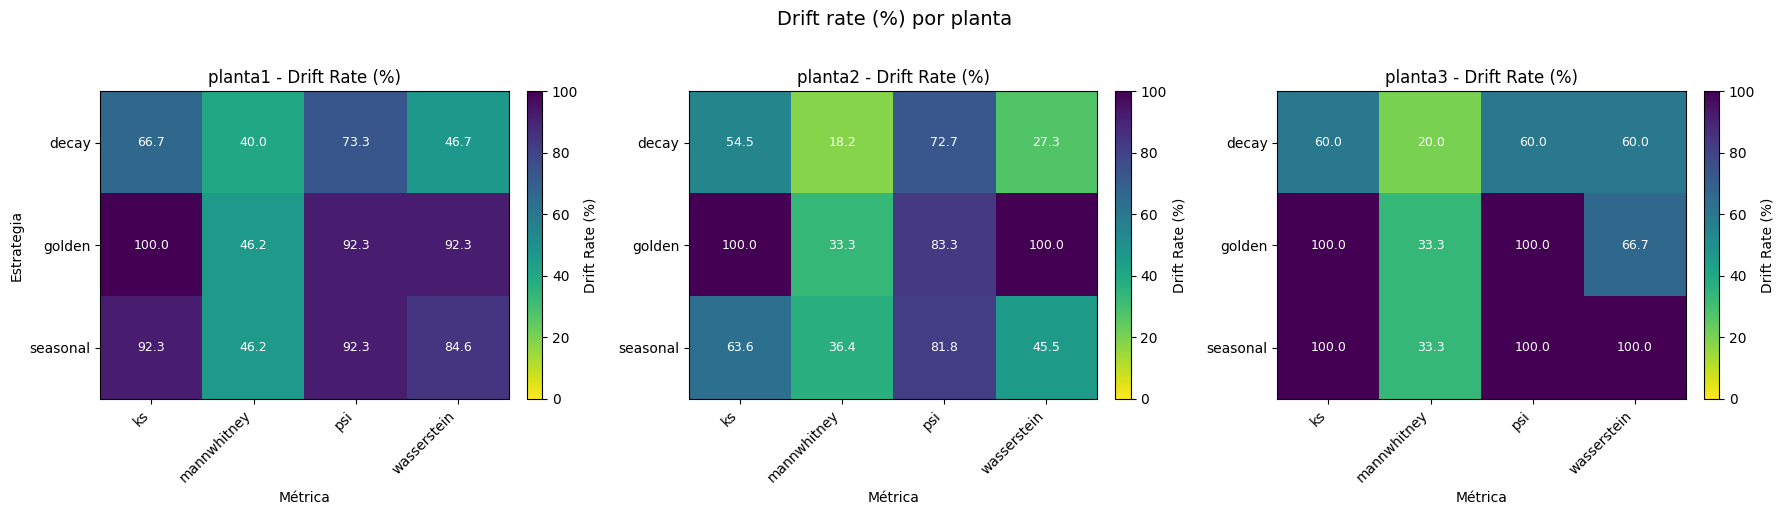

In [ ]:
import matplotlib.pyplot as plt

def plot_heatmap_drift_rate_by_plant(df_summary, title_prefix):
    if df_summary.empty:
        print("Sin datos para graficar."); return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, plant in enumerate(['planta1', 'planta2', 'planta3']):
        subset = df_summary[df_summary['plant'] == plant]
        if subset.empty:
            axes[idx].text(0.5, 0.5, f'No data for {plant}', ha='center', va='center')
            axes[idx].set_title(f"{plant} - Drift Rate (%)")
            continue
            
        pivot = subset.pivot_table(index='strategy', columns='metric', values='drift_rate_pct', aggfunc='mean')
        
        im = axes[idx].imshow(pivot.values, aspect='auto', cmap='viridis_r', vmin=0, vmax=100)
        axes[idx].set_yticks(range(pivot.shape[0]))
        axes[idx].set_yticklabels(pivot.index)
        axes[idx].set_xticks(range(pivot.shape[1]))
        axes[idx].set_xticklabels(pivot.columns, rotation=45, ha='right')
        axes[idx].set_title(f"{plant} - Drift Rate (%)")
        axes[idx].set_xlabel('Métrica')
        if idx == 0:
            axes[idx].set_ylabel('Estrategia')
        
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                text = axes[idx].text(j, i, f'{pivot.values[i, j]:.1f}',
                                     ha="center", va="center", color="white", fontsize=9)
        
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label='Drift Rate (%)')
    
    plt.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_heatmap_drift_rate_by_plant(df_sum_all, "Drift rate (%) por planta")

In [ ]:
rows = []
for (pl, strat), sub in df_cols_all.groupby(['plant','strategy']):
    piv = sub.pivot_table(index='col', columns='metric', values='score', aggfunc='mean')
    if piv.shape[1] >= 2 and piv.dropna().shape[0] >= 3:
        cor = piv.corr()
        rows.append({'plant': pl, 'strategy': strat, 'corr_mean': float(cor.where(~np.eye(len(cor),dtype=bool)).stack().mean())})
corr_df = pd.DataFrame(rows)
display(corr_df.sort_values(['plant','strategy']))

,plant,strategy,corr_mean
0,planta1,decay,0.095944
1,planta1,golden,0.084201
2,planta1,seasonal,0.078640
3,planta2,decay,0.284480
4,planta2,golden,0.017336
5,planta2,seasonal,0.244651
6,planta3,decay,0.738964
7,planta3,golden,0.604911
8,planta3,seasonal,0.580801
